In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from astropy.io import fits

In [7]:
data = fits.open("241031_4227_m1_profiles.fits")
ll = data[0].data

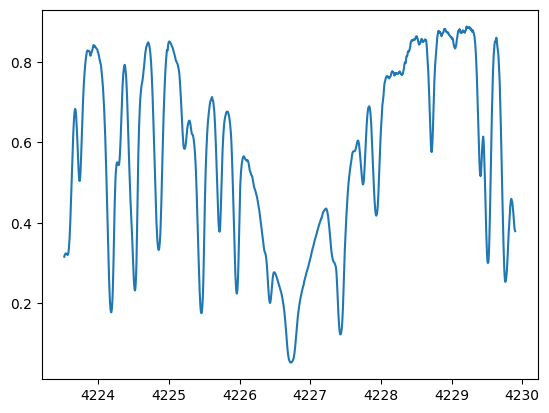

In [8]:
plt.plot(ll, data[1].data[0])

In [9]:
np.savetxt("spectrum.txt", np.c_[ll, data[1].data[0]], fmt="%.6f")

In [10]:
np.savetxt("ca_obs_wave.dat", ll.T, fmt="%.6f", header=str(len(ll)), comments='')

In [11]:
mu = 0.47

In [13]:
theta = np.pi - np.arccos(mu)
print(theta)

2.0600871048090124


## Now we want to explore the opacity that we have calculated. 

In [11]:
op = np.loadtxt("snapi_synth/opacity.dat")
em = np.loadtxt("snapi_synth/emissivity.dat")

In [12]:
print(op.shape)
print(em.shape)

(51, 1200)
(51, 1200)


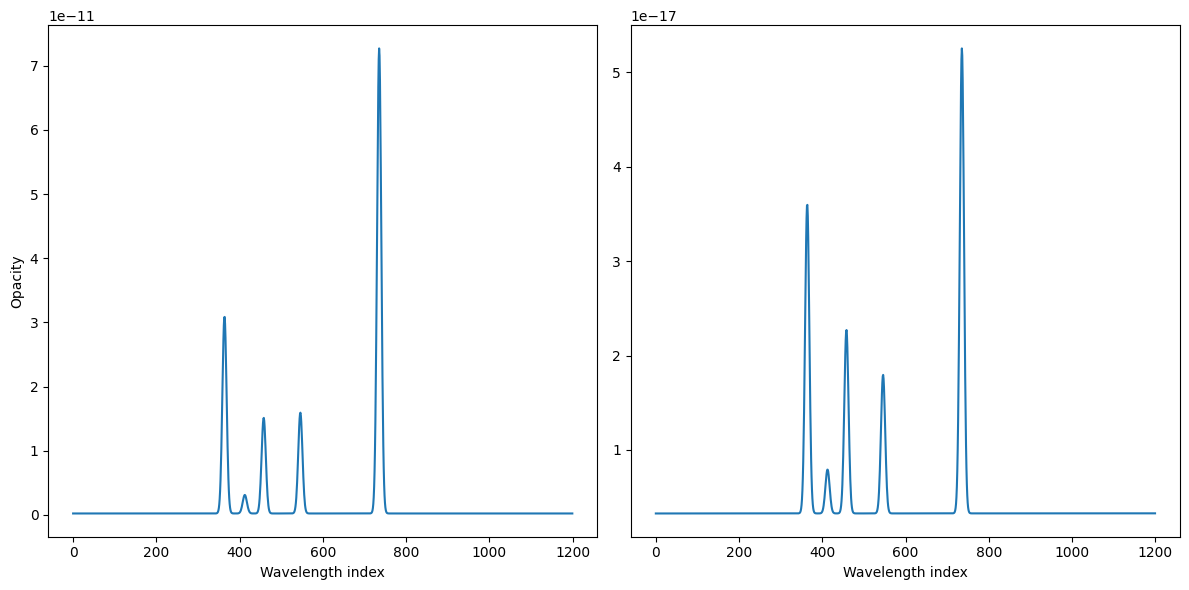

In [13]:
# Same but for opacity, let's do two plots side by side
# in one we will plot the opacity profiles and in the right one we will plot the ratio between them:
d = 25  # depth index to plot
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(op[d,:])
plt.xlabel("Wavelength index")
plt.ylabel("Opacity")
plt.subplot(1,2,2)
plt.plot(em[d,:])
plt.xlabel("Wavelength index")
plt.tight_layout()
plt.savefig("opacity_comparison_continuum.png", dpi=300)